# 示例策略5: 类网格交易策略

- 本策略首先计算过去300个价格数据的均值和标准差 (天数是一个可调参数)
- 并根据均值加减1和2个标准差得到网格的区间分界线,（加减标准差的倍数是可调参数)
- 并分别配以0.3和0.5的仓位权重 (仓位权重是可调参数）
- 然后根据价格所在的区间来配置仓位(+/-40为上下界,无实际意义):
(-40,-3],(-3,-2],(-2,2],(2,3],(3,40](具体价格等于均值+数字倍标准差)
[-0.5, -0.3, 0.0, 0.3, 0.5](资金比例,此处负号表示开空仓，回测时设置为允许持有空头仓位)

回测数据为:HS300指数的1min数据
回测时间为:2017-07-01 08:00:00到2017-10-01 16:00:00

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../'))
# 导入qteasy模块
import qteasy as qt
print(f'qteasy version: {qt.__version__}, datasource: {qt.QT_DATA_SOURCE}')

qteasy version: 2.0.0, datasource: mysql://localhost@3306/ts_db


In [2]:
class GridTrading(qt.GeneralStg):
    
    def __init__(self, pars: tuple = (2.0, 3.0, 0.3, 0.5, 300)):
        super().__init__(
                pars=pars,
                par_count=5,
                par_types=['float', 'float', 'float', 'float', 'int'],  # 仓位配置的阈值：参数1:低仓位阈值，参数2: 高仓位阈值，参数3：低仓位比例，参数4:高仓位比例，参数5:计算天数
                par_range=[(0.5, 3.0), (2.0, 10.), (0.01, 0.5), (0.5, 0.99), (10, 300)],
                name='GridTrading',
                description='根据过去300份钟的股价均值和标准差，改变投资金额的仓位',
                strategy_run_timing='close',  # 在周期结束（收盘）时运行
                strategy_run_freq='1min',  # 每份钟执行一次调整
                strategy_data_types='close',  # 使用份钟收盘价调整
                data_freq='1min',  # 数据频率（包括股票数据和参考数据）
                window_length=300,
                use_latest_data_cycle=False,  # 高频数据不需要使用当前数据区间
                reference_data_types='',  # 不需要使用参考数据
        )
    
    def realize(self, h, r=None, t=None, pars=None):
        """策略输出PT信号，即仓位目标信号"""

        low_threshold, high_threshold, low_pos, hi_pos, days = self.pars

        # 读取最近N天的收盘价
        close = h[:, - days:, 0]  # 最新连续收盘价
        current_close = h[:, -1, 0]  # 当天的收盘价

        # 计算N天的平均价和标准差，并计算仓位阈值
        close_mean = np.nanmean(close, axis=1)
        close_std = np.nanstd(close, axis=1)
        hi_positive = close_mean + high_threshold * close_std
        low_positive = close_mean + low_threshold * close_std
        low_negative = close_mean - low_threshold * close_std
        hi_negative = close_mean - high_threshold * close_std

        # 根据当前的实际价格确定目标仓位，并将目标仓位作为信号输出
        pos = np.zeros_like(close_mean)
        pos = np.where(current_close > hi_positive, hi_pos, pos)
        pos = np.where(hi_positive >= current_close > low_positive, low_pos, pos)
        pos = np.where(low_positive >= current_close > low_negative, 0, pos)
        pos = np.where(low_negative >= current_close > hi_negative, - low_pos, pos)
        pos = np.where(current_close >= hi_negative, - hi_pos, pos)

        return pos


     |                                  |
     |       BACK TESTING RESULT        |
     |                                  |

qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 2 sec 401.7 ms
time consumption for operation back looping:  13 sec 172.3 ms

investment starts on      2022-04-01 09:30:00
ends on                   2022-07-29 15:00:00
Total looped periods:     0.3 years.

-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary

          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000300.SH    42       42     84    0.0%     99.0%      1.0%   

Total operation fee:     ¥   -1,919.41
total investment amount: ¥1,000,000.00
final value:              ¥1,013,449.05
Total return:                      inf% 
Avg Yearly return:                 inf%
Skewness:                          2.69
Kurtosis:                         74.38
Benchmark return:   

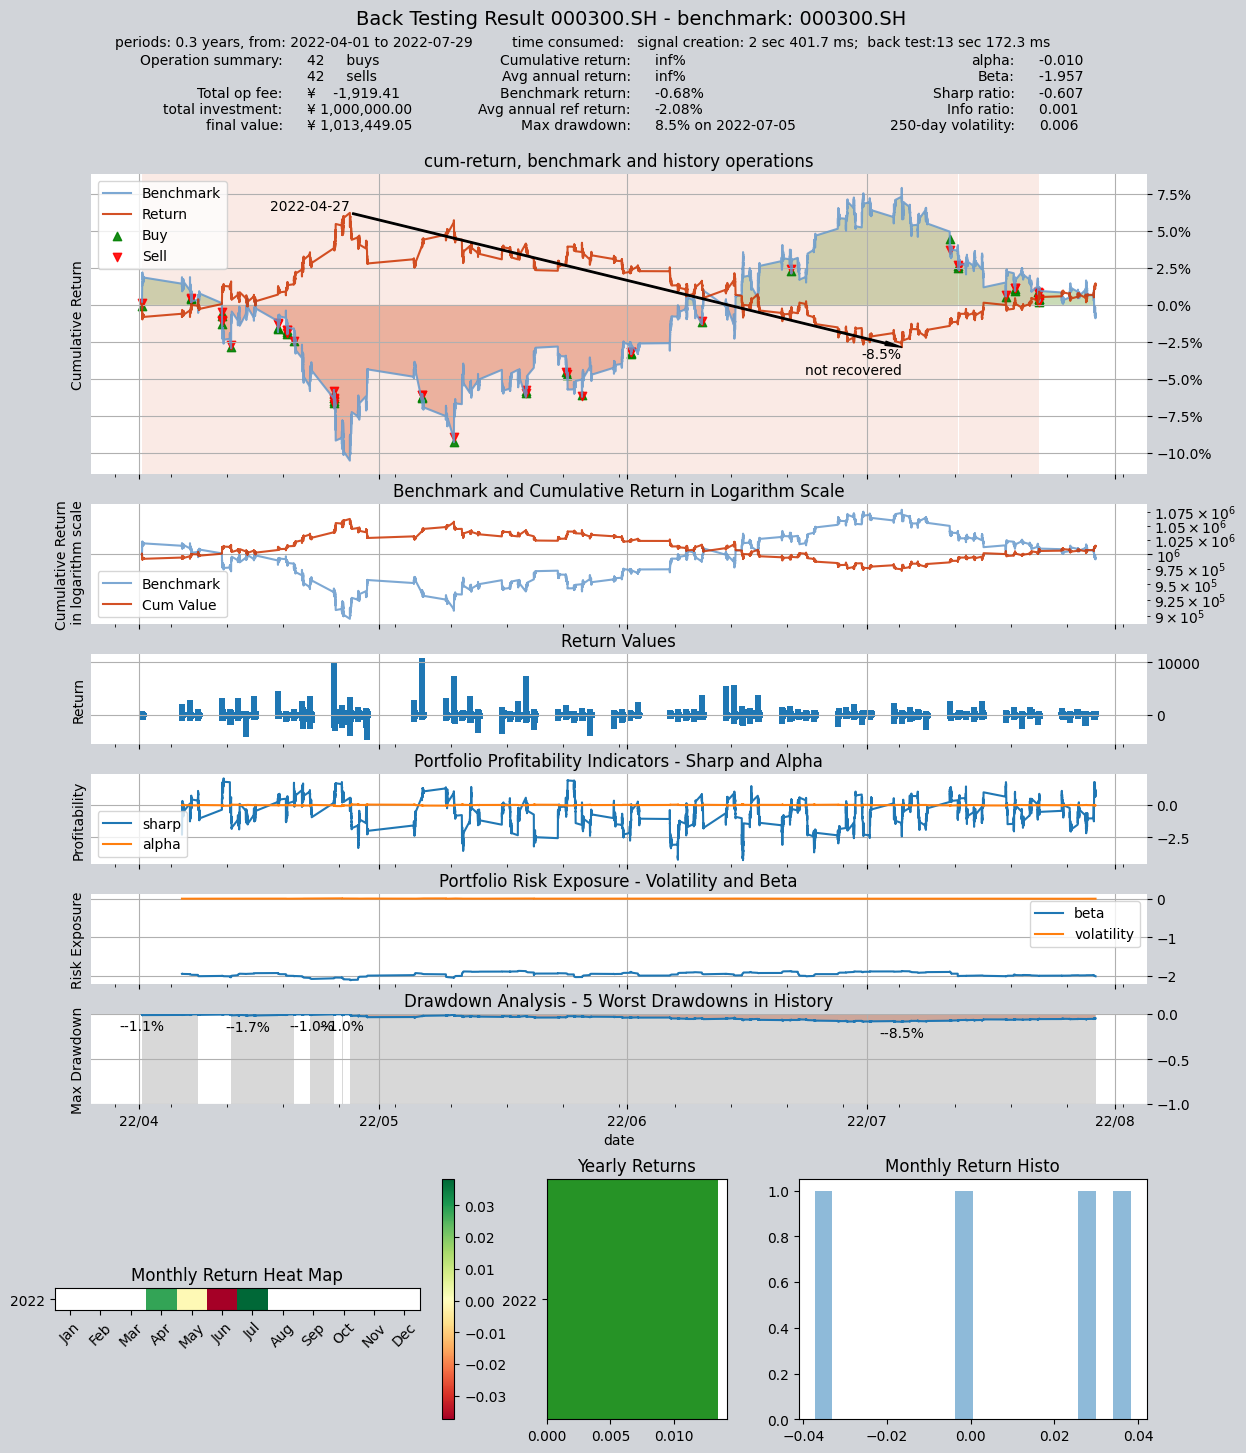

In [3]:
alpha = GridTrading()
op = qt.Operator(alpha, signal_type='PT')
op.op_type = 'batch'
op.set_blender("1.0*s0", 'close')
op.run(
        mode=1,
        invest_start='20220401',
        invest_end='20220731',
        invest_cash_amounts=[1000000],
        asset_type='IDX',
        asset_pool=['000300.SH'],
        trade_batch_size=0,
        sell_batch_size=0,
        trade_log=True,
        allow_sell_short=True,
)

print()